## Example: 2D simulation of Taylor Green Vortex using Lattice Boltzmann Method


The example solves the Naiver Stokes Equation using Lattice Boltzmann Method. Here we setup the problem using an analytical solution of N-S equation: Taylor Green Vortex. Its velocity field and pressure field can be written as


$$u= -u_{\max} \cos \frac{2\pi x}{L} \sin \frac{2\pi y}{L} e^{-\nu t} $$ 

$$ v=u_{\max}\sin \frac{2\pi x}{L} \cos \frac{2\pi y}{L} e^{-\nu t} $$

$$p= -\frac {1}{4}  \rho_0 u_{\max}^2 ( \cos \frac{2\pi x}{L} + \cos \frac{2\pi y}{L} ) e^{-2\nu t} $$

Here, the Boltzmann equation is written as

$$\frac{\partial f}{\partial t}+ \xi_\alpha \frac{\partial f}{\partial x_\alpha} +\frac{f_\alpha}{\rho}\frac{\partial f}{\partial \xi_\alpha}=\Omega(f),$$

where the probability density function $f(\mathbf{x},\mathbf{\xi}, t)$, which is defined as a function of location $\mathbf{x}$, microscopic particle velocity $\mathbf{\xi}$, and time $t$. $f_\alpha$ is external forcing, and $\Omega(f)$ is the collision term.

The problem is solved in 2D using D2Q9 discretization, and the collision term is solved using BGK operator.


## Running the code

The simulation can be ran as `./mained.gnu.ex inputs`. 

The following inputs parameters could be tweaked:

```
scale = 2              # scale of the problem
max_grid_size = 64                # max grid size used for domain decomposition
Nx = 32    # size of the domain in both directions are Nx*scale
NSTEP=200  # number of time steps is NSTEP*scale*scale
plot_int=50 # interval of saving data, if not save, then set as -1
```


## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [1]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset

/tmp/ipykernel_146909/3074286631.py:3: DeprecationWarning: The historic 'boxlib' frontend is 
deprecated as it has been renamed 'amrex'. Existing and future work should instead reference the 'amrex' frontend.
Deprecated since yt 4.4.0
  from yt.frontends.boxlib.data_structures import AMReXDataset


yt : [INFO     ] 2025-05-04 12:14:43,832 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 12:14:43,832 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:14:43,833 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:14:43,834 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 12:14:44,080 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,081 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,082 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,083 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,084 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]



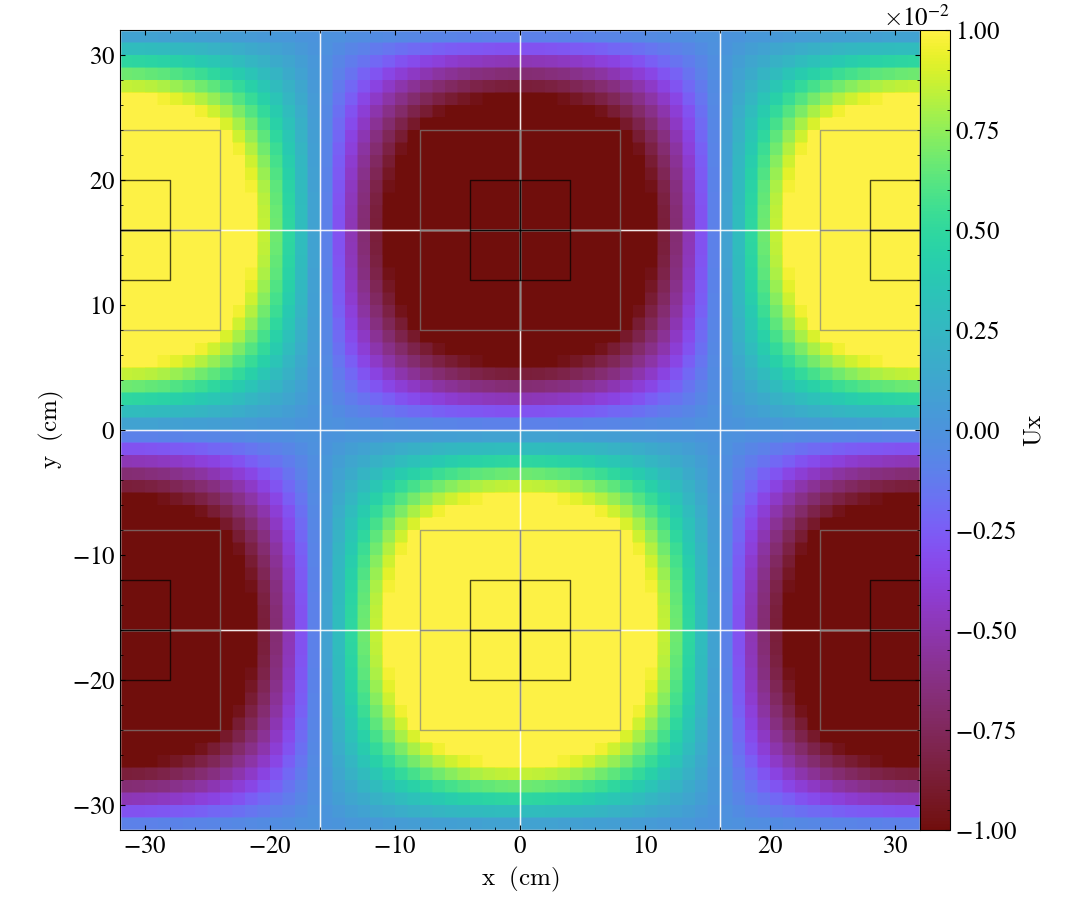

In [2]:
ds = AMReXDataset("plt00000")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -0.01,0.01)

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

yt : [INFO     ] 2025-05-04 12:14:44,602 Parameters: current_time              = 300.0
yt : [INFO     ] 2025-05-04 12:14:44,603 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:14:44,603 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:14:44,604 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 12:14:44,709 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,710 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,712 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,712 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-05-04 12:14:44,714 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800


Available fields: [('boxlib', 'Pressure'), ('boxlib', 'f_new_0'), ('boxlib', 'f_new_1'), ('boxlib', 'f_new_2'), ('boxlib', 'f_new_3'), ('boxlib', 'f_new_4'), ('boxlib', 'f_new_5'), ('boxlib', 'f_new_6'), ('boxlib', 'f_new_7'), ('boxlib', 'f_new_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy'), ('boxlib', 'uz'), ('boxlib', 'vor')]



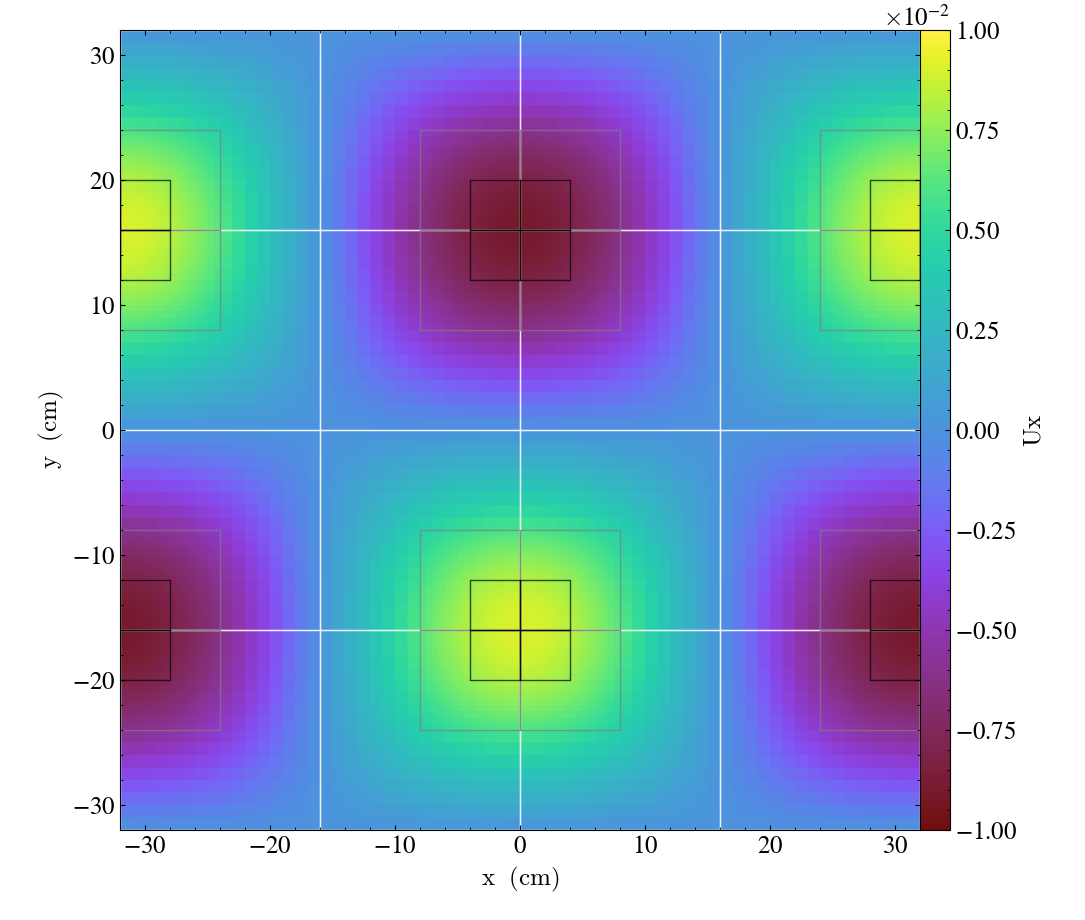

In [3]:
ds = AMReXDataset("plt00300")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux" )

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.set_zlim(field, -0.01,0.01)

slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

## Validation of the results using analytical solution

yt : [INFO     ] 2025-05-04 12:33:53,631 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-05-04 12:33:53,632 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:53,632 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:53,633 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 12:33:54,191 Parameters: current_time              = 50.0
yt : [INFO     ] 2025-05-04 12:33:54,192 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:54,192 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:54,193 Parameters: domain_right_edge         = [64. 64.  1.]


t=0.000 code_time: err_ux=3.941e-04, err_uy=1.079e-04, err_rho=2.558e-04


yt : [INFO     ] 2025-05-04 12:33:54,748 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-05-04 12:33:54,748 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:54,749 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:54,749 Parameters: domain_right_edge         = [64. 64.  1.]


t=50.000 code_time: err_ux=2.545e-02, err_uy=3.067e-02, err_rho=8.643e-01


yt : [INFO     ] 2025-05-04 12:33:55,481 Parameters: current_time              = 150.0
yt : [INFO     ] 2025-05-04 12:33:55,482 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:55,483 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:55,484 Parameters: domain_right_edge         = [64. 64.  1.]


t=100.000 code_time: err_ux=5.824e-02, err_uy=4.818e-02, err_rho=7.230e-01
t=150.000 code_time: err_ux=7.700e-02, err_uy=7.834e-02, err_rho=3.547e-01


yt : [INFO     ] 2025-05-04 12:33:56,486 Parameters: current_time              = 200.0
yt : [INFO     ] 2025-05-04 12:33:56,486 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:56,487 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:56,487 Parameters: domain_right_edge         = [64. 64.  1.]


t=200.000 code_time: err_ux=1.031e-01, err_uy=1.018e-01, err_rho=1.718e+00


yt : [INFO     ] 2025-05-04 12:33:58,138 Parameters: current_time              = 250.0
yt : [INFO     ] 2025-05-04 12:33:58,138 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:58,139 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:58,139 Parameters: domain_right_edge         = [64. 64.  1.]
yt : [INFO     ] 2025-05-04 12:33:59,322 Parameters: current_time              = 300.0
yt : [INFO     ] 2025-05-04 12:33:59,323 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-05-04 12:33:59,323 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-04 12:33:59,324 Parameters: domain_right_edge         = [64. 64.  1.]


t=250.000 code_time: err_ux=1.344e-01, err_uy=1.207e-01, err_rho=8.239e-01
t=300.000 code_time: err_ux=1.514e-01, err_uy=1.551e-01, err_rho=1.066e+00


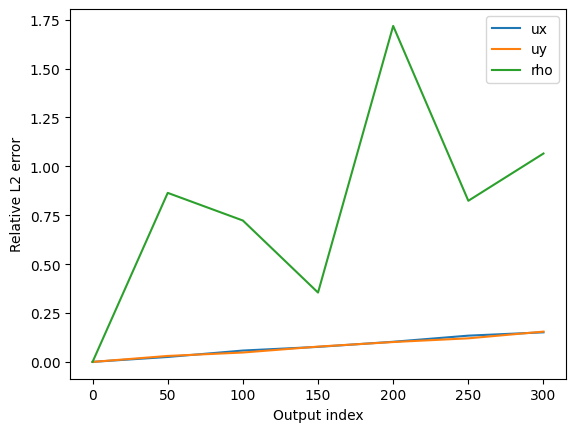

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import yt

L     = 64.0
u_max = 0.02
rho0  = 1.0
kx, ky= 2*np.pi/L, 2*np.pi/L
nu    = 1.0/6.0
td    = 1.0/(nu*(kx*kx + ky*ky))

def u_exact(x, y, z, t):
    decay1 = np.exp(-1.0*t/td)
    decay2 = np.exp(-2.0*t/td)
    ux = -u_max*np.sqrt(ky/kx)*np.cos(kx*x)*np.sin(ky*y)*decay1
    uy =  u_max*np.sqrt(kx/ky)*np.sin(kx*x)*np.cos(ky*y)*decay1
    P  = -0.25*rho0*u_max**2*((ky/kx)*np.cos(2*kx*x)
                             + (kx/ky)*np.cos(2*ky*y))*decay2
    rho= rho0 + 3.0*P
    return ux, uy, rho

times     = np.arange(0, 950, 50)
err_ux    = []
err_uy    = []
err_rho   = []

for idx in times:
    ds     = yt.load(f"plt{idx:05d}")
    t_phys = ds.current_time

    # accumulators for <error^2 * volume> and <ref^2 * volume>
    err2_ux  = ref2_ux  = 0.0
    err2_uy  = ref2_uy  = 0.0
    err2_rho = ref2_rho = 0.0

    # loop over every AMR grid
    for grid in ds.index.grids:
        # cell‐center coords & volume
        x   = grid[("index", "x")].v.flatten()
        y   = grid[("index", "y")].v.flatten()
        z   = grid[("index", "z")].v.flatten()
        vol = grid[("index", "cell_volume")].v.flatten()

        # numeric solution on this grid
        ux_n = grid[("boxlib", "ux")].v.flatten()
        uy_n = grid[("boxlib", "uy")].v.flatten()
        ro_n = grid[("boxlib", "rho")].v.flatten()

        # exact solution at those points
        ux_e, uy_e, ro_e = u_exact(x, y, z, t_phys)

        # errors
        dux  = ux_n - ux_e
        duy  = uy_n - uy_e
        dro  = ro_n - ro_e

        # accumulate
        err2_ux  += np.sum(dux**2 * vol)
        ref2_ux  += np.sum(ux_e**2 * vol)

        err2_uy  += np.sum(duy**2 * vol)
        ref2_uy  += np.sum(uy_e**2 * vol)

        # subtract background for density‐error norm
        err2_rho += np.sum(dro**2 * vol)
        ref2_rho += np.sum((ro_e - rho0)**2 * vol)

    # take square‐root of ratio
    err_ux.append(  np.sqrt(err2_ux  / ref2_ux)  )
    err_uy.append(  np.sqrt(err2_uy  / ref2_uy)  )
    err_rho.append( np.sqrt(err2_rho / ref2_rho) )

    print(f"t={t_phys:.3f}: err_ux={err_ux[-1]:.3e}, "
          f"err_uy={err_uy[-1]:.3e}, err_rho={err_rho[-1]:.3e}")

# plot
plt.plot(times, err_ux,  label='ux')
plt.plot(times, err_uy,  label='uy')
plt.plot(times, err_rho, label='rho')
plt.xlabel('Output index')
plt.ylabel('Relative L2 error')
plt.legend()
plt.show()
